Epoch 0 Loss 0.5547886490821838
Epoch 300 Loss 0.035939380526542664
Epoch 600 Loss 0.025702035054564476
Epoch 900 Loss 0.02218567207455635
Epoch 1200 Loss 0.019608307629823685
Epoch 1500 Loss 0.018040286377072334
Epoch 1800 Loss 0.01678624004125595
Epoch 2100 Loss 0.01700424961745739
Epoch 2400 Loss 0.015138277783989906
Epoch 2700 Loss 0.014699425548315048

===== 欠損点予測 =====

(39,0) 予測=0.2129 真値=0.0000 誤差=0.2129
(54,0) 予測=0.4298 真値=0.0000 誤差=0.4298
(80,0) 予測=0.6906 真値=0.0000 誤差=0.6906
(86,0) 予測=0.7093 真値=0.0000 誤差=0.7093
(114,0) 予測=0.4248 真値=0.0000 誤差=0.4248
(144,0) 予測=0.7326 真値=0.0000 誤差=0.7326
(195,0) 予測=0.4822 真値=0.0000 誤差=0.4822
(212,0) 予測=0.5186 真値=0.0000 誤差=0.5186
(225,0) 予測=0.4393 真値=0.0000 誤差=0.4393
(251,0) 予測=0.4955 真値=0.0000 誤差=0.4955
(253,0) 予測=0.5119 真値=0.0000 誤差=0.5119
(5,1) 予測=0.2790 真値=0.4353 誤差=0.1563
(17,1) 予測=0.3331 真値=0.4157 誤差=0.0826
(18,1) 予測=0.3303 真値=0.4157 誤差=0.0853
(21,1) 予測=0.3156 真値=0.4275 誤差=0.1118
(24,1) 予測=0.2934 真値=0.4118 誤差=0.1183
(79,1) 予測=0.6828 真値=0.7

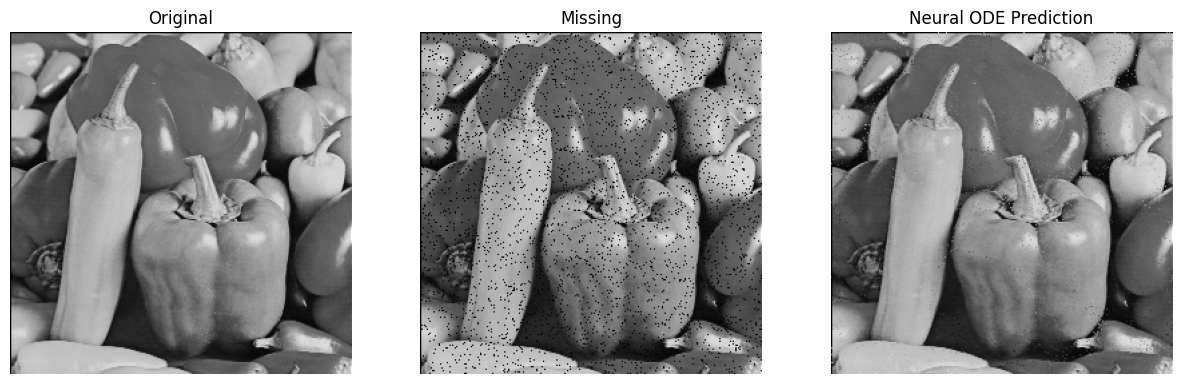

In [ ]:
# ============================================
# Neural ODE 画像欠損補間
# 「既知画素は保持し、欠損画素だけ補間」
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchdiffeq import odeint

# ============
# 画像読み込み
# ============

# 白黒画像として読み込み
img = Image.open("Images/Peppers.png").convert("L")
#.convert("L")で開いた画像を別の色の形式に変換する命令。"L"はグレースケールを意味する。

# 解像度
img = img.resize((256,256))

# numpy化。imgの画像の各画素値0~256の値に変換して配列にする。
# .astype(np.float32)で便宜上データの種類を32ビット浮動小数点数に変換（0→0.0）
img_array = np.array(img).astype(np.float32)

# 画素値（色の数値：0~255の値）を0〜1正規化
img_array = img_array / 255.0

# ========
# 座標作成
# =========

#img_array.shape（.shapeはnumpyの属性）でimg_arrayが縦横何マスなのか取得できる
height, width = img_array.shape

# 座標正規化（重要）
# -1~1までwidthの数だけ分割する処理。これでどんな画像のサイズでも中心が０，端が1、－1となり、統一して計算できる
x = np.linspace(-1,1,width)
y = np.linspace(-1,1,height)

X, Y = np.meshgrid(x, y)

# ===========
# 欠損作成
# =========

# np.ones() は、指定されたサイズで「中身がすべて 1 のデータ」を作る関数
# dtype=boolで数字の１ではなくBoolean型（True/False）に変換。１の場合はTrue
# 後の欠損部分をくりぬく処理で便利
mask = np.ones(img_array.shape, dtype=bool)


# 欠損させるピクセル(座標ランダム版)

np.random.seed(42)

# 全画素の５％のピクセル数
num_missing = int(height * width * 0.05)

indices = np.random.choice(
    height * width,
    num_missing,
    replace=False #「重複無し」の意味。一度選んだピクセルの位置は二度とえらばない→正確にかぶりなく5％分の場所を確保できる
)

missing_points = [
    (idx // width, idx % width)
    for idx in indices
]
"""
#ブロック欠損版
missing_points = []

for i in range(100,156):
    for j in range(100,156):
        missing_points.append((i,j))
# 欠損させるピクセル(座標指定版)

missing_points = [

    (20,20),
    (20,21),
    (20,22),

    (21,20),
    (21,21),
    (21,22),

    (22,20),
    (22,21),
    (22,22),

    (40,40),
    (41,41),
    (42,42)

]
"""
# 欠損化
for i,j in missing_points:

    mask[i,j] = False #欠損にしたい座標(i,j)だけをFalseにする

# 欠損画像
img_missing = img_array.copy() #元データを書き換えないためにコピーを作る

img_missing[~mask] = np.nan #欠損指定した座標だけNaNに置き換える

# =============
# 学習データ作成
# =============

coords = np.stack(
    [X.flatten(), Y.flatten()],
    axis=1
)

targets = img_array.flatten()

mask_flat = mask.flatten()

# 観測点のみ学習
coords_train = coords[mask_flat]

targets_train = targets[mask_flat]

# Tensor化
coords_tensor = torch.tensor(
    coords_train,
    dtype=torch.float32
)

targets_tensor = torch.tensor(
    targets_train,
    dtype=torch.float32
).view(-1,1)

# ==============
# ODE Function
# ーーーーーーー

class ODEFunc(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,128),
            nn.Tanh(),

            nn.Linear(128,2)

        )

    def forward(self, t, h):

        return self.net(h)

#ーーーーーー
# Neural ODE
# ーーーーーーー

class NeuralODEModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.odefunc = ODEFunc()

        self.output_layer = nn.Linear(2,1)

    def forward(self, x_input):

        h0 = x_input

        t = torch.tensor([0,1]).float()

        out = odeint(
            self.odefunc,
            h0,
            t,
            method='rk4'
        )

        h_final = out[-1]

        z_pred = self.output_layer(h_final)

        return z_pred

# ーーーーーーー
# モデル
# ーーーー

model = NeuralODEModel()

criterion = nn.MSELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# ーーーーーーー
# 学習
# ーーーーーー

epochs = 3000

for epoch in range(epochs):

    optimizer.zero_grad()

    pred = model(coords_tensor)

    loss = criterion(
        pred,
        targets_tensor
    )

    loss.backward()

    optimizer.step()

    if epoch % 300 == 0:

        print(
            f"Epoch {epoch} "
            f"Loss {loss.item()}"
        )

# ーーーーーーー
# 全画素予測
#ーーーーーーー

all_coords_tensor = torch.tensor(
    coords,
    dtype=torch.float32
)

with torch.no_grad():

    img_pred = model(
        all_coords_tensor
    ).numpy()

img_pred = img_pred.reshape(
    height,
    width
)

# ーーーーーーー
# 欠損部分だけ補間
# ーーーーーーー

# 既知画素はそのまま
final_img = img_missing.copy()

# 欠損部分だけNeural ODE予測値を代入
final_img[~mask] = img_pred[~mask]

# ーーーーーー
# 欠損点精度表示
# ーーーーーーーー

print("\n===== 欠損点予測 =====\n")

missing_y, missing_x = np.where(~mask)

for idx in range(len(missing_x)):

    x_val = missing_x[idx]
    y_val = missing_y[idx]

    pred_val = final_img[y_val, x_val]

    true_val = img_array[y_val, x_val]

    error = abs(pred_val - true_val)

    print(
        f"({x_val},{y_val}) "
        f"予測={pred_val:.4f} "
        f"真値={true_val:.4f} "
        f"誤差={error:.4f}"
    )

# ーーーーーーー
# 欠損点MSE
# ーーーーー

missing_mse = np.mean(

    (
        img_array[~mask]
        -
        final_img[~mask]

    )**2
)

print("\n==============================")
print("Missing MSE :", missing_mse)
print("==============================")

# ======
# 可視化
# =====
fig, ax = plt.subplots(1,3, figsize=(15,5))

# 元画像
ax[0].imshow(
    img_array,
    cmap='gray'
)

ax[0].set_title("Original")

# 欠損画像
ax[1].imshow(
    np.nan_to_num(img_missing, nan=0),
    cmap='gray'
)

ax[1].set_title("Missing")

# 補間結果
ax[2].imshow(
    final_img,
    cmap='gray'
)

ax[2].set_title("Neural ODE Prediction")

# 軸OFF
for i in range(3):

    ax[i].axis("off")

plt.show()

In [ ]:
# ============================================
# Original vs Missing PSNR

missing_img_for_eval = np.nan_to_num(
    img_missing,
    nan=0
)

mse_original_missing = np.mean(
    (
        img_array
        -
        missing_img_for_eval
    )**2
)

psnr_original_missing = 10 * np.log10(
    1.0 / mse_original_missing
)

print("\n==============================")
print("Original -> Missing PSNR :", psnr_original_missing, "dB")
print("==============================")

missing_region_mse = np.mean(
    (
        img_array[~mask]
        -
        0
    )**2
)

missing_region_psnr = 10 * np.log10(
    1.0 / missing_region_mse
)

print("Original -> Missing Region PSNR :",
      missing_region_psnr, "dB")


Original -> Missing PSNR : 18.631155 dB
Original -> Missing Region PSNR : 5.6197953 dB


In [7]:
#==============================
#元画像から欠損画像についてのpsnr 
#=============================
img_missing_eval = img_missing.copy()

# NaNを0に置換
img_missing_eval = np.nan_to_num(
    img_missing_eval,
    nan=0
)

missing_img_mse = np.mean(
    (img_array - img_missing_eval) ** 2
)

missing_img_psnr = 10 * np.log10(
    1.0 / missing_img_mse
)

print("Missing Image PSNR :", missing_img_psnr, "dB")


# ==============
# 全画像PSNR
# =======

full_mse = np.mean(
    (img_array - final_img) ** 2
)

if full_mse == 0:
    full_psnr = float("inf")
else:
    full_psnr = 10 * np.log10(1.0 / full_mse)

print("\n==============================")
print("Full Image PSNR :", full_psnr, "dB")
print("==============================")

# 元画像から欠損画像の時のpsnr

# 欠損箇所のみのpsnr
missing_mse = np.mean(
    (
        img_array[~mask]
        -
        final_img[~mask]
    ) ** 2
)

if missing_mse == 0:
    missing_psnr = float("inf")
else:
    missing_psnr = 10 * np.log10(1.0 / missing_mse)

print("\n==============================")
print("Missing MSE  :", missing_mse)
print("Missing PSNR :", missing_psnr, "dB")
print("==============================")

# import sys
# !{sys.executable} -m pip install scikit-image

# ===============
# Full Image SSIM
# ==============
from skimage.metrics import structural_similarity as ssim


full_ssim = ssim(
    img_array,
    final_img,
    data_range=1.0
)

print("\n==============================")
print("Full Image SSIM :", full_ssim)
print("==============================")
score, ssim_map = ssim(
    img_array,
    final_img,
    data_range=1.0,
    full=True
)

missing_ssim = np.mean(
    ssim_map[~mask]
)

print("Missing SSIM :", missing_ssim)


Missing Image PSNR : 18.631155 dB

Full Image PSNR : 31.30522 dB

Missing MSE  : 0.014812009
Missing PSNR : 18.29386 dB

Full Image SSIM : 0.9285405155337453
Missing SSIM : 0.9052697
